In [ ]:
# DEVELOPING AN EARLY WARNING SYSTEM FOR STUDENT RETENTION AND ACADEMIC SUCCESS USING MACHINE LEARNING

In [1]:
# ============================================
# STEP 1: PROBLEM UNDERSTANDING AND FRAMING
# ============================================

#Content is available via capstone report documentation

In [ ]:
# ============================================
# STEP 2: DATA COLLECTION AND UNDERSTANDING
# ============================================

In [ ]:
# DATA QUALITY CHECKS

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/dataset.csv')

# Basic overview
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

# Preview data
df.head()

Shape of dataset: (4424, 35)

Columns:
 Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curric

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [ ]:
# Missing values check
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
# Duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Target distribution
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
# Percentage distribution
df['Target'].value_counts(normalize=True) * 100

,proportion
Target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
# Check for negative values in numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if (df[col] < 0).sum() > 0:
        print(f"Negative values found in {col}")

Negative values found in Inflation rate
Negative values found in GDP


In [ ]:
# Check categorical-like columns
categorical_like_cols = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', 'Nacionality',
    'Mother\'s qualification', 'Father\'s qualification',
    'Mother\'s occupation', 'Father\'s occupation'
]

for col in categorical_like_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")


Marital status: 6 unique values

Application mode: 18 unique values

Course: 17 unique values

Previous qualification: 17 unique values

Nacionality: 21 unique values

Mother's qualification: 29 unique values

Father's qualification: 34 unique values

Mother's occupation: 32 unique values

Father's occupation: 46 unique values


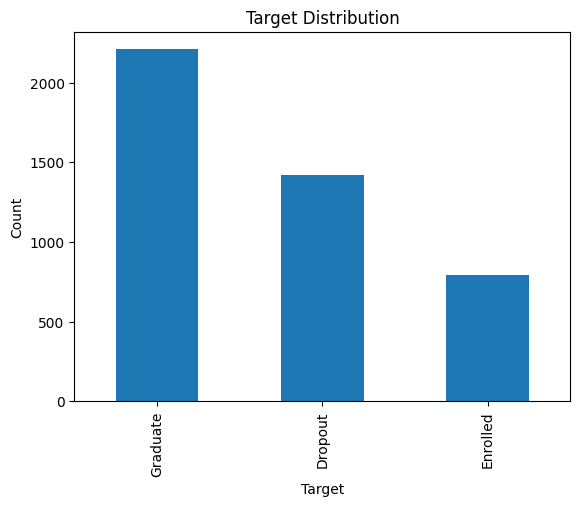

In [ ]:
import matplotlib.pyplot as plt

df['Target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.ylabel("Count")
plt.show()

In [ ]:
# ==============================================================
# STEP 3: DATA PREPROCESSING, APPLIED EDA, & FEATURE ENGINEERING
# ==============================================================

In [ ]:
# BINARY TARGET TRANSFORMATION

import pandas as pd
df = pd.read_csv('/content/dataset.csv')


df['Target_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

# Check new distribution
df['Target_binary'].value_counts(normalize=True) * 100

,proportion
Target_binary,
0,67.879747
1,32.120253


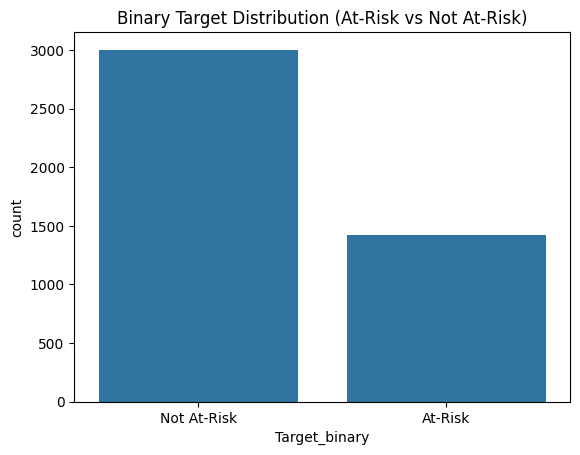

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Binary Target Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target_binary', data=df)
plt.title("Binary Target Distribution (At-Risk vs Not At-Risk)")
plt.xticks([0,1], ['Not At-Risk', 'At-Risk'])
plt.show()

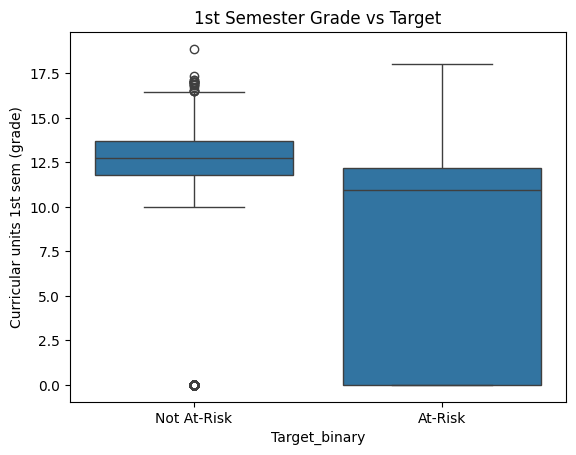

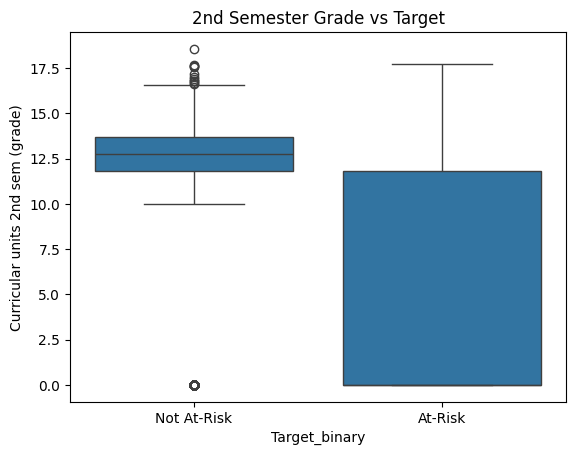

In [ ]:
# Academic Performace vs Target

sns.boxplot(x='Target_binary', y='Curricular units 1st sem (grade)', data=df)
plt.title("1st Semester Grade vs Target")
plt.xticks([0,1], ['Not At-Risk', 'At-Risk'])
plt.show()

sns.boxplot(x='Target_binary', y='Curricular units 2nd sem (grade)', data=df)
plt.title("2nd Semester Grade vs Target")
plt.xticks([0,1], ['Not At-Risk', 'At-Risk'])
plt.show()

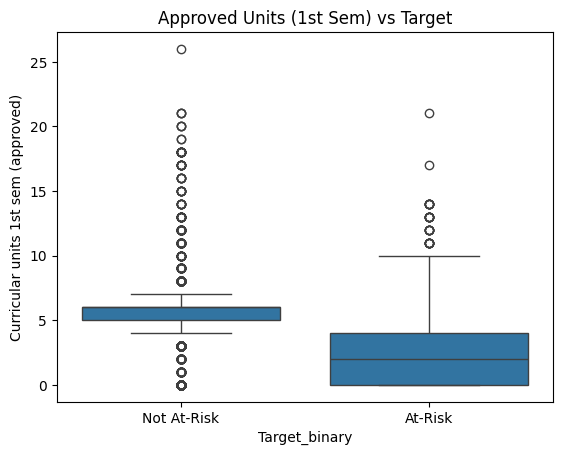

In [ ]:
# Approved Units vs Target

sns.boxplot(x='Target_binary', y='Curricular units 1st sem (approved)', data=df)
plt.title("Approved Units (1st Sem) vs Target")
plt.xticks([0,1], ['Not At-Risk', 'At-Risk'])
plt.show()

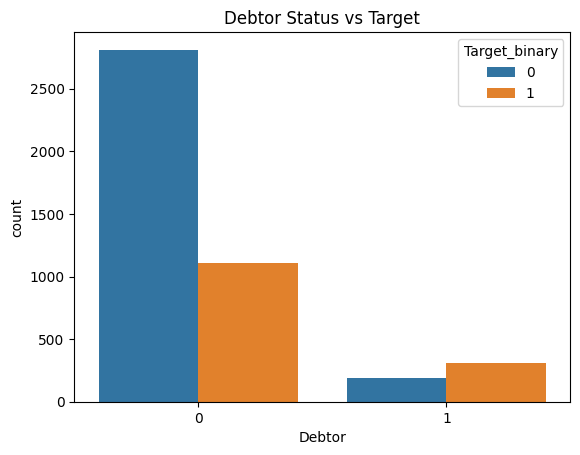

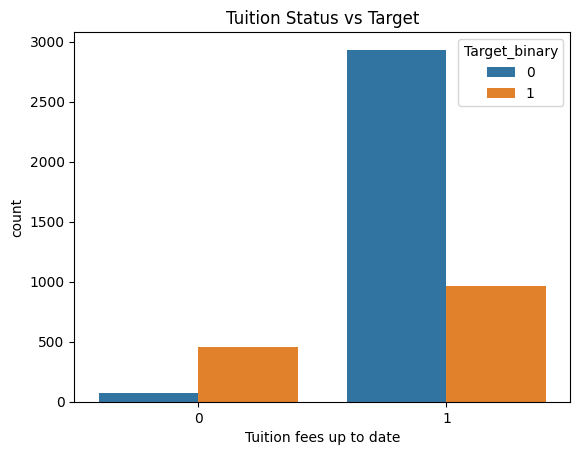

In [ ]:
# Financial Status vs Target

sns.countplot(x='Debtor', hue='Target_binary', data=df)
plt.title("Debtor Status vs Target")
plt.show()

sns.countplot(x='Tuition fees up to date', hue='Target_binary', data=df)
plt.title("Tuition Status vs Target")
plt.show()

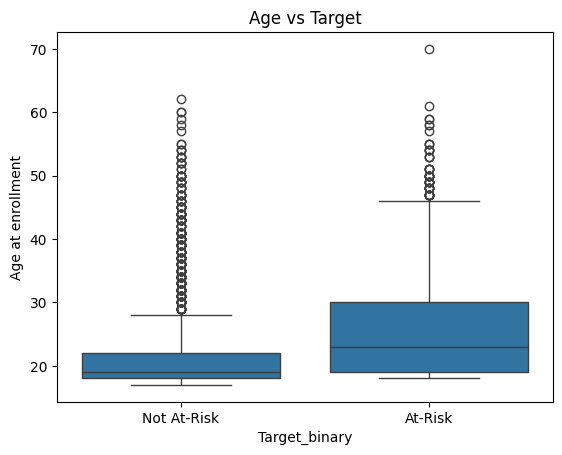

In [ ]:
# Age vs Target

sns.boxplot(x='Target_binary', y='Age at enrollment', data=df)
plt.title("Age vs Target")
plt.xticks([0,1], ['Not At-Risk', 'At-Risk'])
plt.show()

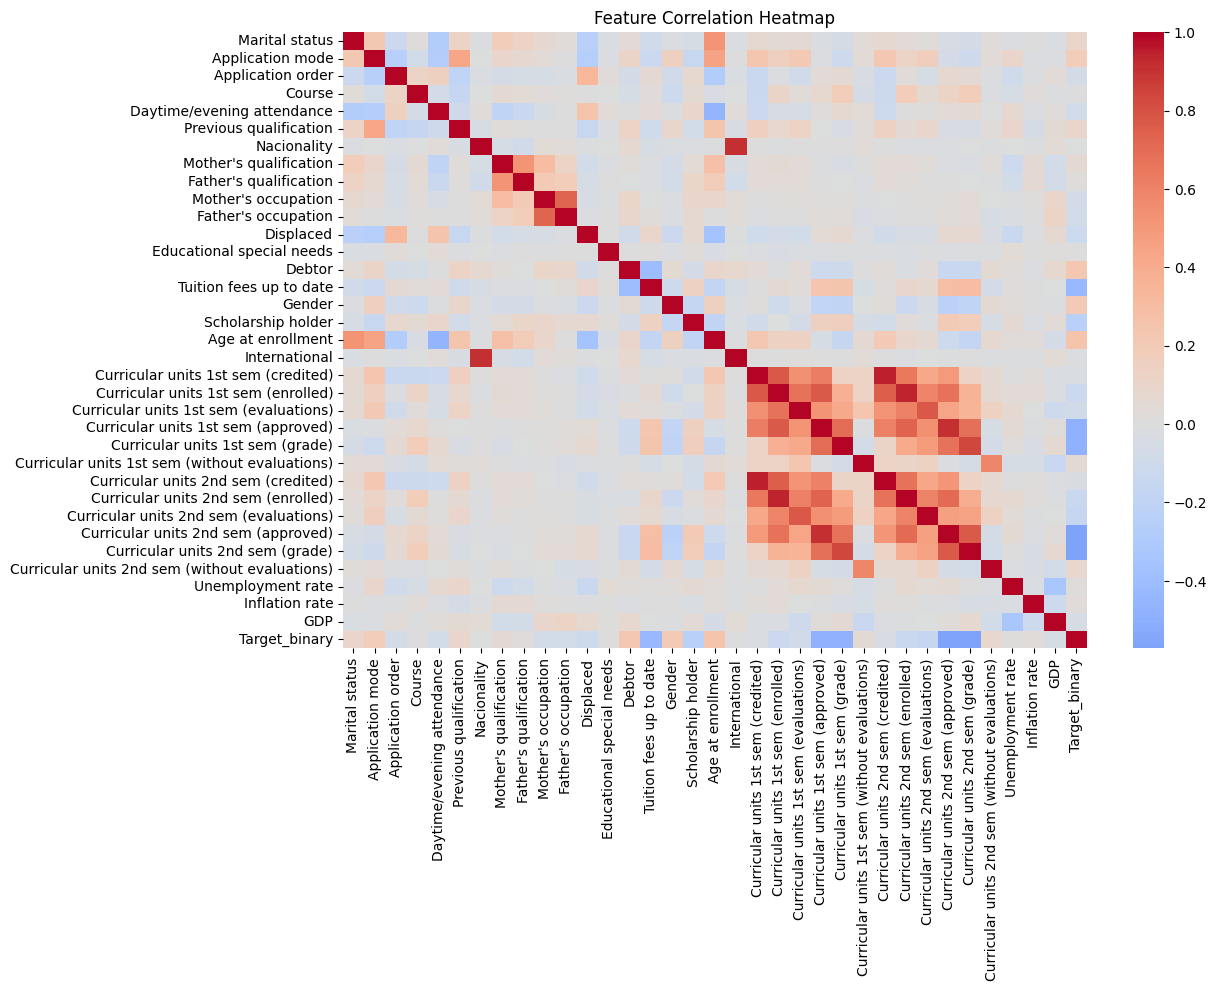

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correlational Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# FEATURE ENGINEERING

import pandas as pd
import numpy as np

# Create engineered academic features
df['Total approved units'] = (
    df['Curricular units 1st sem (approved)'] +
    df['Curricular units 2nd sem (approved)']
)

df['Total enrolled units'] = (
    df['Curricular units 1st sem (enrolled)'] +
    df['Curricular units 2nd sem (enrolled)']
)

df['Total evaluated units'] = (
    df['Curricular units 1st sem (evaluations)'] +
    df['Curricular units 2nd sem (evaluations)']
)

df['Average grade across semesters'] = (
    df['Curricular units 1st sem (grade)'] +
    df['Curricular units 2nd sem (grade)']
) / 2

# Avoid division by zero
df['Approval rate 1st sem'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)

df['Approval rate 2nd sem'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'],
    0
)

df['Overall approval rate'] = np.where(
    df['Total enrolled units'] > 0,
    df['Total approved units'] / df['Total enrolled units'],
    0
)

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,GDP,Target,Target_binary,Total approved units,Total enrolled units,Total evaluated units,Average grade across semesters,Approval rate 1st sem,Approval rate 2nd sem,Overall approval rate
0,1,8,5,2,1,1,1,13,10,6,...,1.74,Dropout,1,0,0,0,0.000000,0.000000,0.000000,0.000000
1,1,6,1,11,1,1,1,1,3,4,...,0.79,Graduate,0,12,12,12,13.833333,1.000000,1.000000,1.000000
2,1,1,5,5,1,1,1,22,27,10,...,1.74,Dropout,1,0,12,0,0.000000,0.000000,0.000000,0.000000
3,1,8,2,15,1,1,1,23,27,6,...,-3.12,Graduate,0,11,12,18,12.914286,1.000000,0.833333,0.916667
4,2,12,1,3,0,1,1,22,28,10,...,0.79,Graduate,0,11,12,15,12.666667,0.833333,1.000000,0.916667


In [ ]:
# Separating Feature and Target

# Drop original multiclass target and keep binary target
X = df.drop(columns=['Target', 'Target_binary'])
y = df['Target_binary']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4424, 41)
Target shape: (4424,)


In [ ]:
# Identifying Feature Types

# Columns that are encoded categoricals
categorical_cols = [
    'Marital status',
    'Application mode',
    'Course',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

# Binary columns
binary_cols = [
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Daytime/evening attendance'
]

# Numerical columns = everything else
numerical_cols = [col for col in X.columns if col not in categorical_cols + binary_cols]

print("Categorical columns:", len(categorical_cols))
print("Binary columns:", len(binary_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 9
Binary columns: 8
Numerical columns: 24


In [ ]:
# Splitting Data for Train and Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (3539, 41)
X_test shape: (885, 41)
y_train distribution:
 Target_binary
0    0.678723
1    0.321277
Name: proportion, dtype: float64
y_test distribution:
 Target_binary
0    0.679096
1    0.320904
Name: proportion, dtype: float64


In [ ]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for each feature type
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Application order', 'Age at enrollment',
                                  'Curricular units 1st sem (credited)',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricular units 1st sem (grade)',
                                  'Curricular units 1st sem (without '
                                  'evaluations)',
                                  'Curricular units 2nd sem (credited)',
                                  'Curri...
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital status', 'Application mode',
                                  'Course', 'Previous qualification',
                                  'Nacionality', "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation",
                                  "Father's occupation"]),
                                ('bin', 'passthrough',
                                 ['Displaced', 'Educational special needs',
                                  'Debtor', 'Tuition fees up to date', 'Gender',
                                  'Scholarship holder', 'International',
                                  'Daytime/evening attendance'])])

In [ ]:
# Testing Preprocessor Output

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (3539, 240)
Processed X_test shape: (885, 240)


In [ ]:
# FEATURE SELECTION - MODEL-BASED (RANDOM FOREST)

from sklearn.ensemble import RandomForestClassifier

# Fit model on processed data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
importances = rf.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(15)

,Feature,Importance
22,num__Approval rate 2nd sem,0.074799
23,num__Overall approval rate,0.069353
11,num__Curricular units 2nd sem (approved),0.064506
20,num__Average grade across semesters,0.058623
17,num__Total approved units,0.057398
12,num__Curricular units 2nd sem (grade),0.048809
235,bin__Tuition fees up to date,0.043404
5,num__Curricular units 1st sem (approved),0.041450
21,num__Approval rate 1st sem,0.040757
6,num__Curricular units 1st sem (grade),0.037109


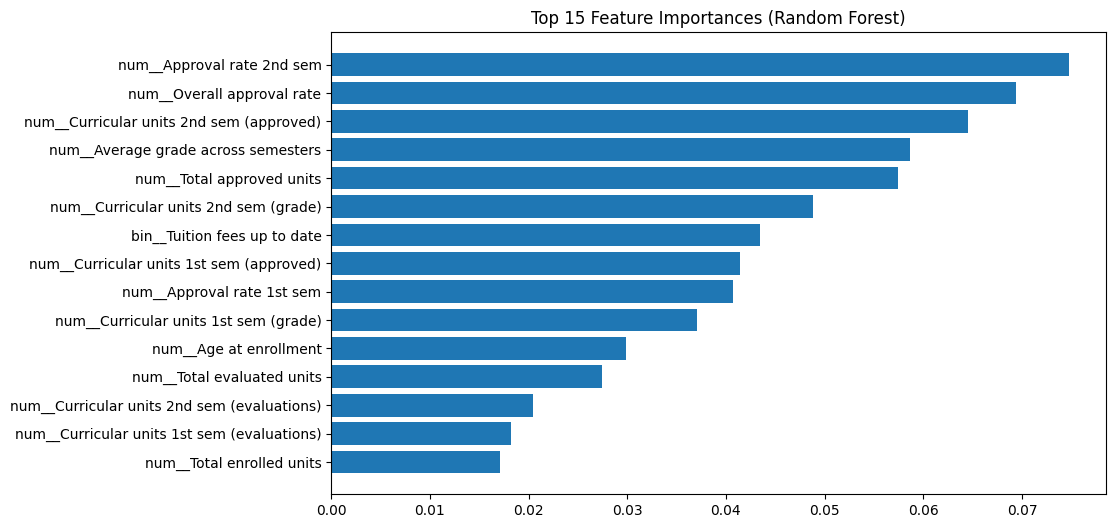

In [ ]:
# Visualize Top Features

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

In [ ]:
# PCA ANALYSIS

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_processed)

explained_variance = pca.explained_variance_ratio_

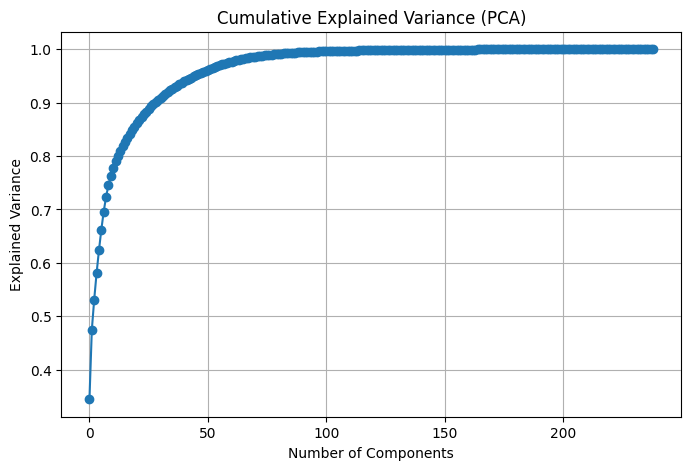

In [ ]:
# Plotting Explained Variance

import numpy as np

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance (PCA)")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.grid()
plt.show()

In [ ]:
# =============================
# STEP 4: MODEL IMPLEMENTATION
# =============================

In [ ]:
# Defining Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [ ]:
# Model Training and Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.883616,0.872428,0.746479,0.804554,0.934344
0,Logistic Regression,0.888136,0.874494,0.760563,0.813559,0.931370
3,SVM,0.882486,0.905405,0.707746,0.794466,0.926666
4,XGBoost,0.898305,0.864662,0.809859,0.836364,0.925892
1,Decision Tree,0.818079,0.711340,0.728873,0.720000,0.794553


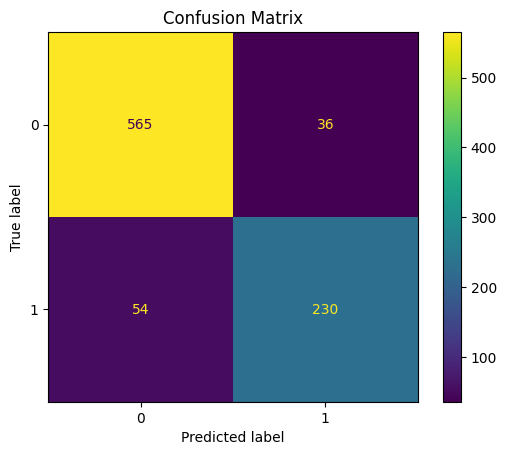

In [ ]:
# CONFUSION MATRIX (BEST MODEL)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Replace with best model later
best_pipeline = pipeline

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

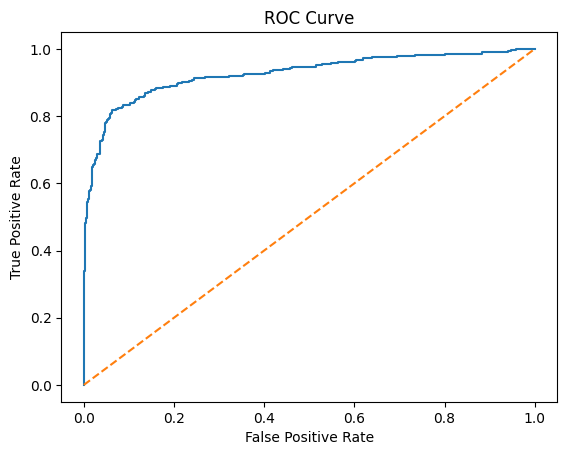

In [ ]:
# ROC CURVE

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
import joblib
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported for best_pipeline construction

# Ensure results_df is defined by running the model training and evaluation cell (1Jympk9PZZzd) first.
# If results_df is not available, this cell will raise a NameError.
try:
    # Identify the best model based on ROC-AUC
    best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]['Model']

    # Create the pipeline for the best model
    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[best_model_name])
    ])

    # Train the best pipeline with the identified best model
    best_pipeline.fit(X_train, y_train)

    # SAVE BEST MODEL
    joblib.dump(best_pipeline, 'best_model.pkl')
    print(f"Model '{best_model_name}' saved as 'best_model.pkl'")
except NameError as e:
    if "results_df" in str(e):
        print("Error: 'results_df' is not defined. Please ensure cell '1Jympk9PZZzd' (Model Training and Evaluation) has been executed successfully before running this cell.")
    else:
        print(f"A NameError occurred: {e}. Please check if all necessary variables (e.g., 'models', 'preprocessor', 'X_train', 'y_train') are defined by running previous cells.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Model 'Random Forest' saved as 'best_model.pkl'


In [ ]:
import joblib

# LOAD MODEL

loaded_model = joblib.load('best_model.pkl')

In [ ]:
# ============================================
# STEP 5: ETHICAL AI & BIAS AUDITING
# ============================================

In [ ]:
# SHAP Explainability

import shap
import pandas as pd
import numpy as np

# Fit best pipeline
best_pipeline.fit(X_train, y_train)

# Extract fitted preprocessor and model
fitted_preprocessor = best_pipeline.named_steps['preprocessor']
model = best_pipeline.named_steps['model']

# Transform training data
X_train_processed = fitted_preprocessor.transform(X_train)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

# Get feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Create DataFrame with transformed features
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

# Sample for SHAP to keep it manageable
X_shap = X_train_processed_df.sample(n=min(500, len(X_train_processed_df)), random_state=42)

# Tree explainer
explainer = shap.TreeExplainer(model)

# Disable additivity check
shap_values = explainer.shap_values(X_shap, check_additivity=False)

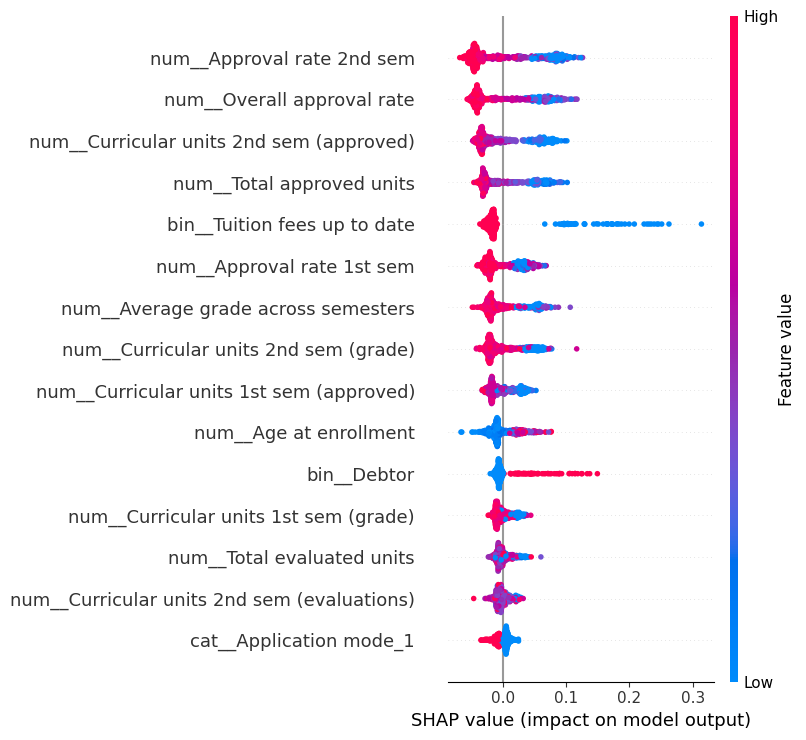

In [ ]:
# SHAP Summary Plot

shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(
    shap_values_class1,
    X_shap,
    feature_names=X_shap.columns,
    max_display=15
)

In [ ]:
print(X_shap.shape)
print(np.array(shap_values).shape)

(500, 240)
(500, 240, 2)


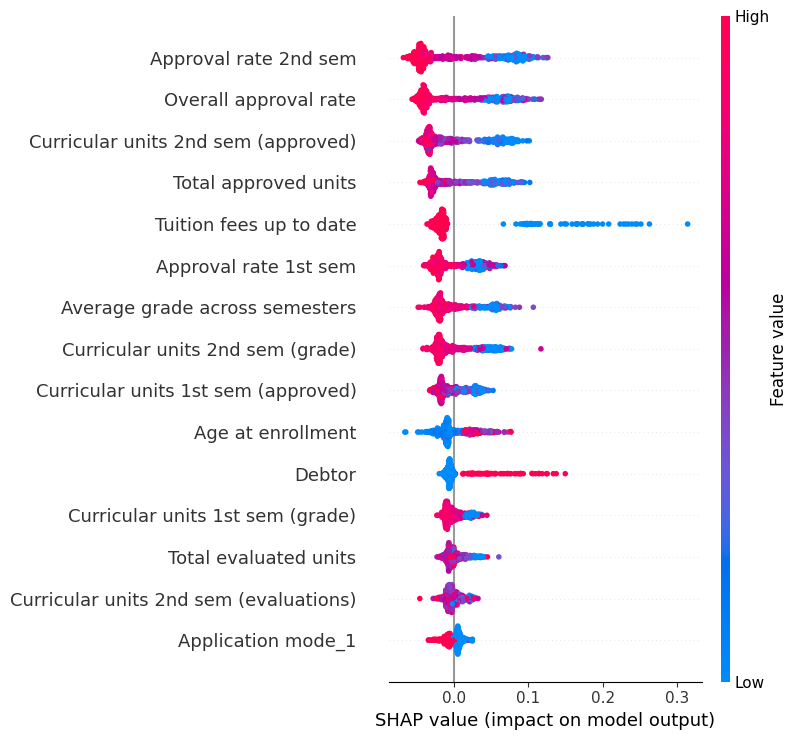

In [ ]:
# Clean names for SHAP

clean_names = [col.replace("num__", "").replace("cat__", "").replace("bin__", "") for col in X_shap.columns]
X_shap_clean = X_shap.copy()
X_shap_clean.columns = clean_names

shap.summary_plot(
    shap_values[:, :, 1],
    X_shap_clean,
    feature_names=X_shap_clean.columns,
    max_display=15
)

In [ ]:
# Fairness Check - Gender

import pandas as pd

# Add predictions
df_test = X_test.copy()
df_test['Actual'] = y_test
df_test['Predicted'] = best_pipeline.predict(X_test)

# Group by gender
fairness_gender = df_test.groupby('Gender')[['Actual', 'Predicted']].mean()

fairness_gender

,Actual,Predicted
Gender,,
0,0.244681,0.191489
1,0.454829,0.420561


In [ ]:
# Fairness Check - Age Group
#

df_test['Age_group'] = pd.cut(df_test['Age at enrollment'], bins=[17,20,25,30,40,70])

fairness_age = df_test.groupby('Age_group')[['Actual', 'Predicted']].mean()

fairness_age

/tmp/ipykernel_11103/3762584668.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fairness_age = df_test.groupby('Age_group')[['Actual', 'Predicted']].mean()


,Actual,Predicted
Age_group,,
"(17, 20]",0.198830,0.148148
"(20, 25]",0.356688,0.312102
"(25, 30]",0.589744,0.525641
"(30, 40]",0.600000,0.550000
"(40, 70]",0.561404,0.578947
